# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Устанавливаем модуль psycopg2
!pip install psycopg2-binary 

In [2]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [3]:
# Данные для подключенния с базе данных
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             } 

In [4]:
# Формируем строки для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [5]:
# Передаем строки для подключения функции create_engine()
engine = create_engine(connection_string)

In [6]:
# Формируем запрос
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk order_dt,
    created_ts_msk order_ts,
    currency_code,
    revenue,
    tickets_count,
    created_dt_msk::date - LAG(created_dt_msk::date) OVER (PARTITION BY user_id ORDER BY created_dt_msk) days_since_prev,
    event_id,
    event_name_code event_name, 
    service_name,
    event_type_main,
    region_name,
    city_name   
FROM afisha.purchases
JOIN afisha.events USING(event_id)
JOIN afisha.city USING(city_id)
JOIN afisha.regions USING(region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND
    event_type_main != 'фильм'
ORDER BY user_id;
'''

In [7]:
# Записываем результата SQL-запроса в датафрейм
df = pd.read_sql_query(query, con=engine)

1. Установили модуль psycopg2 (для работы с PostgreSQL в Python), библиотеки pandas, matplotlib.pyplot, seaborn и функцию create_engine из библиотеки sqlalchemy для создания соединения с базой данных.
2. Подключились к базе данных.
3. Через SQL-запрос выгрузили датафрейм.

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
# Выводим информацию о датафрейме
df.info()

# Выводим первые 5 строк датафрейма на экран
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [9]:
# Считаем пропуски
col_with_null = [c for c in df.columns if df[c].isnull().any()]
count_null = df['days_since_prev'].isna().sum()
percentage_of_null = round(df['days_since_prev'].isna().sum() / df['days_since_prev'].shape[0]*100,2)

# Формируем список полей в разрезе типа данных 
int_col = list(df.select_dtypes('int'))
fl_col = list(df.select_dtypes('float'))
dt_col = list(df.select_dtypes('datetime64'))
obj_col = list(df.select_dtypes('object'))

print(f'''
1. Изучили общую информацию о выгруженных данных и оценили корректность выгрузки и объём полученных данных:
    - Названия, описание полей и их значения соответствуют друг другу. 
    - Датасет содержит {df.shape[0]} строк и {df.shape[1]} столбцов.
    - Пропуски обнаружены {'в столбце' if len(col_with_null) == 1 else 'В столбцах'} {", ".join(col for col in col_with_null)} в количестве {count_null} строк. Доля пропусков составляет {percentage_of_null} % от общего объема строк.
    - Датасет содержит: 
         - {len(int_col)} поля c целочисленным типом данных: {", ".join(col for col in int_col)}.
         - {len(fl_col)} поля c вещественным типом данных: {", ".join(col for col in fl_col)}. 
         - {len(dt_col)} поля c типом данных дата и дата/время: {", ".join(col for col in dt_col)}. 
         - {len(obj_col)} полей c текстовым типом данных: {", ".join(col for col in obj_col)}.
    - Явных дубликатов найдено {df.duplicated().sum()} строк.
    
2. На этапе предобработки данных необходимо сделать следующие шаги:
     - оптимизируем числовые данные с помощью понижения разрядности и преобразуем тип данных у категориальных столбцов;
     - проверим категориальные столбцы и столбец с названием билетного оператора на наличие неявных дубликатов;
     - проанализируем найденные пропуски;
     - проверим важные для анализа числовые показатели на наличие аномальных значений или выбросов.
''')


1. Изучили общую информацию о выгруженных данных и оценили корректность выгрузки и объём полученных данных:
    - Названия, описание полей и их значения соответствуют друг другу. 
    - Датасет содержит 290611 строк и 15 столбцов.
    - Пропуски обнаружены в столбце days_since_prev в количестве 21933 строк. Доля пропусков составляет 7.55 % от общего объема строк.
    - Датасет содержит: 
         - 3 поля c целочисленным типом данных: order_id, tickets_count, event_id.
         - 2 поля c вещественным типом данных: revenue, days_since_prev. 
         - 2 поля c типом данных дата и дата/время: order_dt, order_ts. 
         - 8 полей c текстовым типом данных: user_id, device_type_canonical, currency_code, event_name, service_name, event_type_main, region_name, city_name.
    - Явных дубликатов найдено 0 строк.
    
2. На этапе предобработки данных необходимо сделать следующие шаги:
     - оптимизируем числовые данные с помощью понижения разрядности и преобразуем тип данных у категориаль

---

###  Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [10]:
# Выгружаем данные
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

# Выводим информацию о датафрейме
final_tickets_tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Столбец `data` имеет текстовой тип данных, для слияния таблиц изменим тип данных столбца на тип данных `дата`.

In [11]:
# Изменяем тип данных столбца 'data' на datetime64[ns]
final_tickets_tenge_df['data'] = final_tickets_tenge_df['data'].astype('datetime64[ns]')

In [12]:
# Объединяем таблицы
df_merge = df.merge(final_tickets_tenge_df, left_on=['order_dt','currency_code'], right_on=['data','cdx'], how='left')

# Добавляем столбец 'revenue_rub'
df['revenue_rub'] = df_merge.apply(lambda r: 
    r['revenue'] if r['currency_code'] == 'rub' else r['revenue'] / 100 * r['curs'], axis=1)

# Выводим первые 5 строк датафрейма на экран
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк,1390.41


In [13]:
# сохраняем объём памяти, который занимает датасет перед предобработкой
m_u_1 = round(df.memory_usage().sum()/1048576,2)

In [14]:
print(f'''
1. Перед конвертацией изменили тип данных в столбце data в датасете final_tickets_tenge_df.csv на {final_tickets_tenge_df['data'].dtype}. 
2. Привели выручку к российскому рублю.
3. Сохранили результат в новый столбец revenue_rub.
''')


1. Перед конвертацией изменили тип данных в столбце data в датасете final_tickets_tenge_df.csv на datetime64[ns]. 
2. Привели выручку к российскому рублю.
3. Сохранили результат в новый столбец revenue_rub.



---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [15]:
# Считаем пропуски в датафрейме
df.isna().sum().to_frame(name='count_null')

,count_null
user_id,0
device_type_canonical,0
order_id,0
order_dt,0
order_ts,0
currency_code,0
revenue,0
tickets_count,0
days_since_prev,21933
event_id,0


In [16]:
# Оптимизируем текстовой тип данных в датафрейме
obj_col = ['device_type_canonical','currency_code', 'event_type_main','region_name','city_name']
for column in obj_col:
    df[column] = df[column].astype('category')

# Оптимизируем целочисленный тип данных в датафрейме
int_col = ['order_id','tickets_count','event_id']
for column in int_col:
    df[column] = pd.to_numeric(df[column], downcast='integer')
    
# Оптимизируем вещественный тип данных в датафрейме
fl_col = ['revenue','days_since_prev', 'revenue_rub']
for column in fl_col:
    df[column] = pd.to_numeric(df[column], downcast='float')
    
# Выводим информацию о датафрейме
df.info()

m_u_2 = round(df.memory_usage().sum()/1048576,2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  cate

In [17]:
# Проверяем уникальные значения в категориальных столбцах и в столбеце с названим билетного оператора
for column in ['device_type_canonical','currency_code', 'event_type_main','region_name','city_name']:
    print(f'Уникальные значения в столбце {column}:', ", ".join(col for col in list(df[column].cat.categories)))
    print()

# Проверяем уникальные значения в текстовых столбцах
print(f'Уникальные значения в столбце service_name:', ", ".join(col for col in list(df['service_name'].sort_values().unique())))

Уникальные значения в столбце device_type_canonical: desktop, mobile

Уникальные значения в столбце currency_code: kzt, rub

Уникальные значения в столбце event_type_main: выставки, другое, концерты, спорт, стендап, театр, ёлки

Уникальные значения в столбце region_name: Белоярская область, Берестовский округ, Берёзовская область, Боровлянский край, Верховинская область, Верхозёрский край, Верхоречная область, Ветренский регион, Вишнёвский край, Глиногорская область, Голубевский округ, Горицветская область, Горноземский регион, Горностепной регион, Дальнеземская область, Дальнезорский край, Дубравная область, Залесский край, Заречная область, Зеленоградский округ, Златопольский округ, Золотоключевской край, Зоринский регион, Каменевский регион, Каменичская область, Каменноозёрный край, Каменноярский край, Каменополянский округ, Ключеводский округ, Кристаловская область, Кристальная область, Крутоводская область, Крутоводский регион, Лесноярский край, Лесодальний край, Лесополянская обл

In [18]:
# Выводим статистические показатели
statistical_indicators_df = df[['revenue_rub','tickets_count']].describe().round(2)
statistical_indicators_df

,revenue_rub,tickets_count
count,290611.00,290611.00
mean,555.57,2.75
std,875.50,1.17
min,-90.76,1.00
25%,113.97,2.00
50%,351.14,3.00
75%,802.05,4.00
max,81174.54,57.00


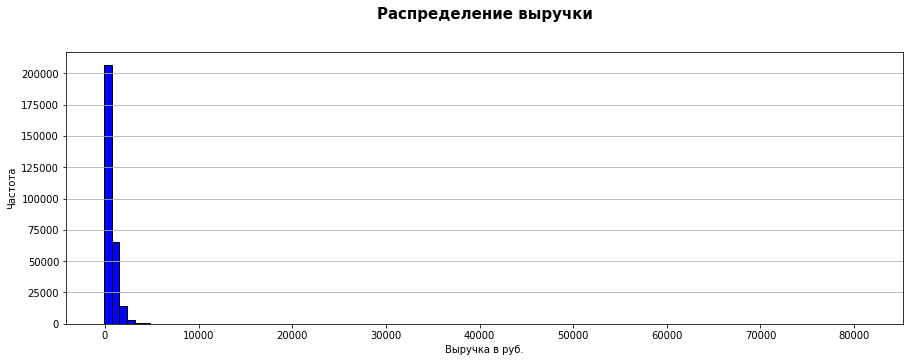

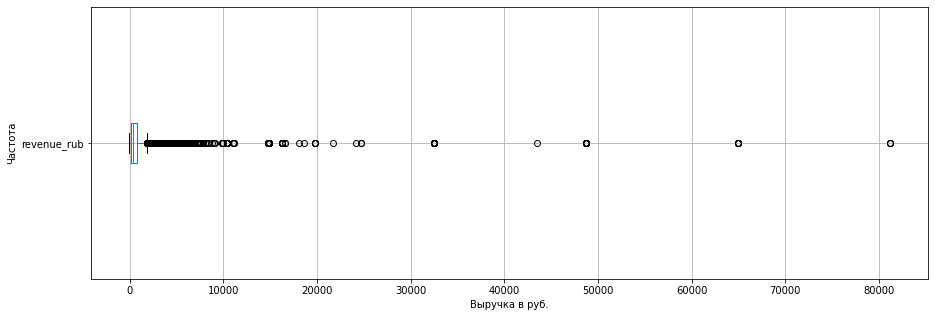

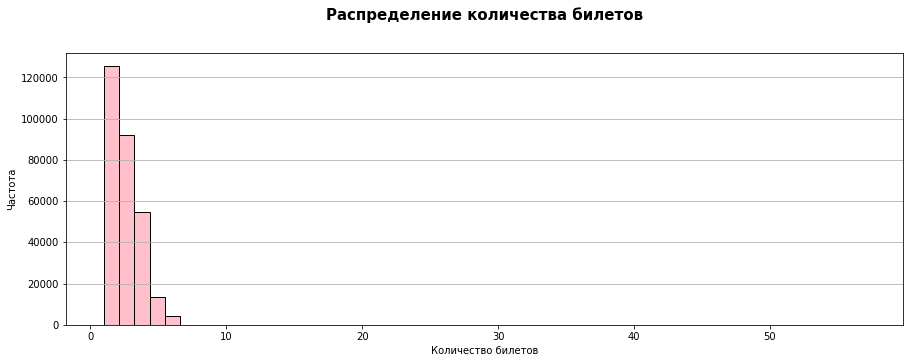

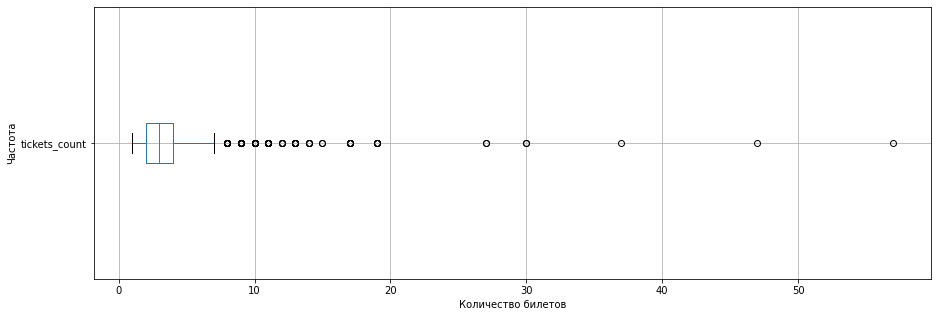

In [19]:
# revenue_rub ------------------------------------------------------------------------------------------------------------------

# Строим гистограмму -----------------------------------------------------------------------------------------------------------

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5)) 
df['revenue_rub'].plot(
    kind='hist', 
    bins=100, 
    rot=0, 
    color = 'blue', 
    edgecolor='black')
# Настраиваем оформление графика
plt.title('Распределение выручки', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Выручка в руб.')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid(axis='y')
# Выводим график
plt.show()

# Строим "ящик с усами" --------------------------------------------------------------------------------------------------------

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))
# Строим диаграмму размаха значений в столбце revenue_rub
df.boxplot(column='revenue_rub', vert=False)
# Добавляем заголовок и метки оси
plt.xlabel('Выручка в руб.')
plt.ylabel('Частота')
# Выводим график
plt.show()

# tickets_count ----------------------------------------------------------------------------------------------------------------

# Строим гистограмму -----------------------------------------------------------------------------------------------------------

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5)) 
df['tickets_count'].plot(
    kind='hist', 
    bins=50, 
    rot=0, 
    color = 'pink', 
    edgecolor='black')
# Настраиваем оформление графика
plt.title('Распределение количества билетов', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid(axis='y')
# Выводим график
plt.show()

# Строим "ящик с усами" --------------------------------------------------------------------------------------------------------

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))
# Строим диаграмму размаха значений в столбце tickets_count
df.boxplot(column='tickets_count', vert=False)
# Добавляем заголовок и метки оси
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
# Выводим график
plt.show()

In [20]:
#найдем выбросы revenue_rub с помощью IQR
Q1_r = df['revenue_rub'].quantile(0.25)
Q3_r = df['revenue_rub'].quantile(0.75)
IQR_r = Q3_r - Q1_r
lower_r = Q1_r - 1.5 * IQR_r
upper_r = Q3_r + 1.5 * IQR_r
out_revenue_rub = df[(df['revenue_rub'] < lower_r) | (df['revenue_rub'] > upper_r)]

#найдем выбросы tickets_count с помощью IQR
Q1_t = df['tickets_count'].quantile(0.25)
Q3_t = df['tickets_count'].quantile(0.75)
IQR_t = Q3_t - Q1_t
lower_t = Q1_t - 1.5 * IQR_t
upper_t = Q3_t + 1.5 * IQR_t
out_tickets_count = df[(df['tickets_count'] < lower_t) | (df['tickets_count'] > upper_t)]

print(f'''
Количество выбросов в столбце revenue_rub: {len(out_revenue_rub)}
Количество выбросов в столбце tickets_count: {len(out_tickets_count)}
''')



Количество выбросов в столбце revenue_rub: 10449
Количество выбросов в столбце tickets_count: 126



In [21]:
# определим 99 перцентиль
percentile_99th = df['revenue_rub'].quantile(0.99)
print(f'99 перцентиль равен {round(percentile_99th)} руб.')

# найдем количество выбросов
out_revenue_rub = df['revenue_rub'] > percentile_99th

# исключим выбросы из данных
df = df[df['revenue_rub'] <= percentile_99th]

99 перцентиль равен 2628 руб.


In [22]:
# Выводим статистические показатели после фильтрации
print('Cтатистические показатели revenue_rub и tickets_count после фильтрации:')
statistical_indicators_df_filtered = df[['revenue_rub','tickets_count']].describe().round(2)
statistical_indicators_df_filtered

Cтатистические показатели revenue_rub и tickets_count после фильтрации:


,revenue_rub,tickets_count
count,287786.00,287786.00
mean,518.03,2.74
std,511.96,1.16
min,-90.76,1.00
25%,111.85,2.00
50%,343.85,3.00
75%,788.66,3.00
max,2628.42,57.00


Сравним статистические показатели до и после фильтрации в столбце `revenue_rub`.

In [23]:
# # Объединим таблицы для сравнения
statistical_indicators_df_with_filter = statistical_indicators_df.join(statistical_indicators_df_filtered, lsuffix='_unfiltered', rsuffix='_filtered')

# Выведем статистические данные по столбцу revenue_rub
statistical_indicators_df_with_filter_ = statistical_indicators_df_with_filter[['revenue_rub_unfiltered','revenue_rub_filtered']]
statistical_indicators_df_with_filter_

,revenue_rub_unfiltered,revenue_rub_filtered
count,290611.00,287786.00
mean,555.57,518.03
std,875.50,511.96
min,-90.76,-90.76
25%,113.97,111.85
50%,351.14,343.85
75%,802.05,788.66
max,81174.54,2628.42


In [24]:
print(f'''
1. Пропуски проверены, они встречаются только в столбце {", ".join(col for col in col_with_null)} в количестве {count_null} строк. 
Пропуск означает, что у пользователя была только 1 покупка, поэтому количество дней от предыдущей покупки пользователя рассчитать невозможно.

2. Были преобразованы типы данных в столбцах с текстовым типом данных. 

    - Тип данных в текстовых столбцах {", ".join(col for col in obj_col)} был изменен на тип данных 'category'.
    - Типы данных в числовых столбцах {", ".join(col for col in int_col+fl_col)} оптимизированы с  помощью снижения разрядности.
        - Разрядность в столбцах с вещественным типом данных {", ".join(col for col in fl_col)} была понижена до float32. 
        - Разрядность в столбцах с целочисленным типом {", ".join(col for col in int_col)} была понижена до int32 и int8.  

В результате использование памяти уменьшилось на {m_u_1 - m_u_2} МВ ({round((1 - m_u_2/m_u_1)*100)}%).

3. В столбцах с номинальными данными указаны категории типа устройства, валюта, тип мероприятия, название города и региона. 
Среди категорий нет таких, которые означали бы пропуски в данных или отсутствие информации. 
Приводить нормализацию данных, нет необходимости, так как неявных дубликатов нет.

4. Для проверки распределения были выведены статистические показатели, построена гистограммы распределения и диаграммы размаха по важным для анализа показателям - выручка с заказа и количество билетов в заказе.
    
    - Распределение выручки говорит о том, что в данные имеют аномально высокие значения и выбросы. Это подтверждают:
        - Статистические показатели:
            - стандартное отклонение ({statistical_indicators_df.iloc[2,0]}) больше среднего значения ({statistical_indicators_df.iloc[1,0]}); 
            - среднее значение больше медианы ({statistical_indicators_df.iloc[5,0]});
            - максимальное значение ({statistical_indicators_df.iloc[7,0]}) сильно превышает медиану.
        - У гистограммы правый хвост длиннее левого.
        - Диаграммы размаха имеет длинный правый «ус», который длиннее левого. На графике присутствуют выбросы, которые сильно удалены от максимума значений без учета аномалий.
        - IQR равен {len(out_revenue_rub)}, то есть количество выбросов составляет {len(out_revenue_rub)/df['revenue_rub'].count()*100:.2f}% от общего количества строк.
    
    - Распределение количества билетов говорит о том, что в данные имеют выбросы, но разброс данных небольшой. Это подтверждают:
        - Статистические показатели:
            - стандартное отклонение ({statistical_indicators_df.iloc[2,1]}) меньше среднего значения ({statistical_indicators_df.iloc[1,1]}); 
            - среднее значение меньше медианы ({statistical_indicators_df.iloc[5,1]});
            - максимальное значение ({statistical_indicators_df.iloc[7,1]}) превышает медиану.
        - Гистограмма имеет правоассиметричное распределение, у которого правый хвост длиннее левого.
        - Диаграммы размаха имеет длинный правый «ус», который длиннее левого. На графике присутствуют выбросы, которые сильно удалены от максимума значений без учета аномалий.
        - IQR равен {len(out_tickets_count)}, то есть количество выбросов составляет {len(out_tickets_count)/df['tickets_count'].count()*100:.2f}% от общего количества строк.

Выбросы говорят о том, что большинство заказывают дешевы билеты и в меньшем количестве, чем дорогие билеты и в большом объеме.

Минимальное значение выручки отрицательное, что говорит о наличии возвратов. Всего возвратов {df[df['revenue_rub'] < 0].shape[0]}, что составляет {df[df['revenue_rub'] < 0].shape[0]/df['revenue_rub'].count()*100:.2f}% от общего количества строк.

5. Критические выбросы обнаружены в столбце revenue_rub, поэтому отфильтровали данные по 99 перцентилю. 
Удалили {out_revenue_rub.sum()} строк с аномально высокой выручкой. Их доля составляет {round(out_revenue_rub.mean()*100,2)} % от общего количества строк.
После фильтрации значений по 99 перцентилю осталось {df.shape[0]} строк.

После фильтрации:
    - стандартное отклонение снизилось c {statistical_indicators_df_with_filter_.iloc[2,0]} до {statistical_indicators_df_with_filter_.iloc[2,1]};
    - среднее значение снизилось c {statistical_indicators_df_with_filter_.iloc[1,0]} до {statistical_indicators_df_with_filter_.iloc[1,1]};
    - медиана значение снизилось c {statistical_indicators_df_with_filter_.iloc[5,0]} до {statistical_indicators_df_with_filter_.iloc[5,1]};
    - максимальное значение снизилось c {statistical_indicators_df_with_filter_.iloc[7,0]} до {statistical_indicators_df_with_filter_.iloc[7,1]};.

После удаления аномальных выбросов данные стали более стабильны, у них меньший размах и разброс данных.
''')



1. Пропуски проверены, они встречаются только в столбце days_since_prev в количестве 21933 строк. 
Пропуск означает, что у пользователя была только 1 покупка, поэтому количество дней от предыдущей покупки пользователя рассчитать невозможно.

2. Были преобразованы типы данных в столбцах с текстовым типом данных. 

    - Тип данных в текстовых столбцах device_type_canonical, currency_code, event_type_main, region_name, city_name был изменен на тип данных 'category'.
    - Типы данных в числовых столбцах order_id, tickets_count, event_id, revenue, days_since_prev, revenue_rub оптимизированы с  помощью снижения разрядности.
        - Разрядность в столбцах с вещественным типом данных revenue, days_since_prev, revenue_rub была понижена до float32. 
        - Разрядность в столбцах с целочисленным типом order_id, tickets_count, event_id была понижена до int32 и int8.  

В результате использование памяти уменьшилось на 16.9 МВ (48%).

3. В столбцах с номинальными данными указаны категории ти

---

### Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [25]:
# отсортируем данные по времени совершения заказа
df = df.sort_values('order_dt')

# группируем и агригируем данные
user_profile = df.groupby('user_id').agg(
    date_of_first_order = ('order_dt', 'min'), # дата первого заказа 
    date_of_last_order = ('order_dt', 'max'), # дата последнего заказа  
    device_of_first_order = ('device_type_canonical', 'first'), # устройство, с которого был сделан первый заказ
    region_of_first_order = ('region_name', 'first'), # регион, в котором был сделан первый заказ
    service_of_first_order = ('service_name', 'first'), # билетный партнёр, к которому обращались при первом заказе
    genre_of_first_order = ('event_type_main', 'first'), # жанр первого посещённого мероприятия
    total_number_of_orders = ('order_id', 'count'), # общее количество заказов
    average_revenue_in_rubles = ('revenue_rub', 'mean'), # средняя выручка с одного заказа в рублях
    average_number_of_tickets = ('tickets_count', 'mean'), # среднее количество билетов в заказе
    average_time_between_orders = ('days_since_prev', 'mean') # среднее время между заказами
).reset_index()


user_profile['is_two'] = (user_profile['total_number_of_orders'] >= 2) * 1
user_profile['is_five'] = (user_profile['total_number_of_orders'] >= 5) * 1

user_profile.head()

,user_id,date_of_first_order,date_of_last_order,device_of_first_order,region_of_first_order,service_of_first_order,genre_of_first_order,total_number_of_orders,average_revenue_in_rubles,average_number_of_tickets,average_time_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.939941,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010010,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213318,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830017,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.309998,1.500000,16.0,1,0


In [26]:
print(f'Построили профиль пользователя, который включает в себя столбцы {", ".join(col for col in user_profile.columns)}.')

Построили профиль пользователя, который включает в себя столбцы user_id, date_of_first_order, date_of_last_order, device_of_first_order, region_of_first_order, service_of_first_order, genre_of_first_order, total_number_of_orders, average_revenue_in_rubles, average_number_of_tickets, average_time_between_orders, is_two, is_five.


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [27]:
# Расчитаем показатели, используя данные о профилях пользователей
total_number_of_users = user_profile['user_id'].count()
average_revenue = round(user_profile['average_revenue_in_rubles'].mean())
share_is_two = round(user_profile['is_two'].mean() * 100)
share_is_five = round(user_profile['is_five'].mean() * 100)

print(f'''
Ключевые показатели профиля пользователя:

Общее число пользователей в выборке - {total_number_of_users};
Cредняя выручка с одного заказа - {average_revenue} руб.;
Доля пользователей, совершивших 2 и более заказа - {share_is_two}%;
Доля пользователей, совершивших 5 и более заказов - {share_is_five}%.
''')


Ключевые показатели профиля пользователя:

Общее число пользователей в выборке - 21854;
Cредняя выручка с одного заказа - 544 руб.;
Доля пользователей, совершивших 2 и более заказа - 62%;
Доля пользователей, совершивших 5 и более заказов - 29%.



In [28]:
# Изучим статистические показатели
print('Cтатистические показатели профиля пользователя:')
user_profile_describe = user_profile[['total_number_of_orders','average_number_of_tickets','average_time_between_orders']].describe().round(2)
user_profile_describe

Cтатистические показатели профиля пользователя:


,total_number_of_orders,average_number_of_tickets,average_time_between_orders
count,21854.00,21854.00,13521.00
mean,13.17,2.74,15.84
std,121.67,0.91,22.30
min,1.00,1.00,0.00
25%,1.00,2.00,1.00
50%,2.00,2.75,8.00
75%,5.00,3.08,20.40
max,10181.00,11.00,148.00


In [29]:
print(f'''
1. Используя данные о профилях пользователей рассчитали общее число пользователей ({total_number_of_users}), среднюю выручку ({average_revenue} руб.), долю пользователей, совершивших 2 и более заказа ({share_is_two}%) и долю пользователей, совершивших 5 и более заказов ({share_is_five}%).

2. Изучили статистические показатели по общему числу заказов, по среднему числу билетов и по среднему количеству дней между покупками.

Данные показали наличие выбросов данных в столбце total_number_of_orders: 
    - стандартное отклонение ({user_profile_describe.iloc[2,0]}) больше среднего значения ({user_profile_describe.iloc[1,0]}),
    - среднее значение больше медианы ({user_profile_describe.iloc[5,0]});
    - максимальное значение ({user_profile_describe.iloc[7,0]}) превышает медиану.
Выбросы говорят о том, что есть пользователи, которые оформили более {user_profile_describe.iloc[7,0]} заказов. Это, очевидно, относится к аномальным значениям. 

Статистический анализ столбца average_number_of_tickets показывает наличие выбросов, но не критичных:
    - стандартное отклонение ({user_profile_describe.iloc[2,1]}) меньше среднего значения ({user_profile_describe.iloc[1,1]}),
    - среднее значение и медиана ({user_profile_describe.iloc[5,1]}) равны, что указывает на симметричность распределения.
    - максимальное значение ({user_profile_describe.iloc[7,1]}) превышает медиану. 
Здесь выброс говорит, что 1 пользователь купил 11 билетов, что вполне возможно, например, при организации коллективной поездки на концерт. 

Статистический анализ столбца average_time_between_orders также показывает наличие выбросов, но не критичных:
    - стандартное отклонение ({user_profile_describe.iloc[2,2]}) больше среднего значения ({user_profile_describe.iloc[1,2]}),
    - среднее значение больше медианы ({user_profile_describe.iloc[5,2]}), что указывает на правоассимитричное распределение.
    - максимальное значение ({user_profile_describe.iloc[7,2]}) превышает медиану.
Здесь выброс указывает на пользователя, который редко покупает билеты. 

3. По результатам можно сделать вывод, что данных достаточно по объёму. Это подтверждают показатели 'Общее число пользователей в выборке' и 'Доля пользователей, совершивших 2 и более заказа'.
    - {total_number_of_users} пользователей - это вполне достаточный объем для анализа. 
    - Высокая доля пользователей, совершивших 2 и более заказа - {share_is_two}% - говорит о том, что большинство пользователей вернулись, поэтому можно отследить взаимосвязь с другими показателями и построить надежную модель для прогноза возврата клиента.

4. Аномальные значения найдены в столбце total_number_of_orders. Чтобы исключить влияние экстремальных выбросов на результат, отфильтруем данные по 99-му перцентилю.
''')


1. Используя данные о профилях пользователей рассчитали общее число пользователей (21854), среднюю выручку (544 руб.), долю пользователей, совершивших 2 и более заказа (62%) и долю пользователей, совершивших 5 и более заказов (29%).

2. Изучили статистические показатели по общему числу заказов, по среднему числу билетов и по среднему количеству дней между покупками.

Данные показали наличие выбросов данных в столбце total_number_of_orders: 
    - стандартное отклонение (121.67) больше среднего значения (13.17),
    - среднее значение больше медианы (2.0);
    - максимальное значение (10181.0) превышает медиану.
Выбросы говорят о том, что есть пользователи, которые оформили более 10181.0 заказов. Это, очевидно, относится к аномальным значениям. 

Статистический анализ столбца average_number_of_tickets показывает наличие выбросов, но не критичных:
    - стандартное отклонение (0.91) меньше среднего значения (2.74),
    - среднее значение и медиана (2.75) равны, что указывает на симметри

In [30]:
# определим 99 перцентиль
percentile_99th = user_profile['total_number_of_orders'].quantile(0.99)

# найдем количество выбросов
out_total_number_of_orders = user_profile['total_number_of_orders'] > percentile_99th

# исключим выбросы из данных
user_profile = user_profile[user_profile['total_number_of_orders'] <= percentile_99th]

In [31]:
# изучим статистические показатели после фильтрации
print('Cтатистические показатели профиля пользователя после фильтрации:')
user_profile_describe_filtered = user_profile[['total_number_of_orders','average_number_of_tickets','average_time_between_orders']].describe().round(2)
user_profile_describe_filtered

Cтатистические показатели профиля пользователя после фильтрации:


,total_number_of_orders,average_number_of_tickets,average_time_between_orders
count,21638.00,21638.00,13305.00
mean,6.50,2.74,16.09
std,14.32,0.92,22.39
min,1.00,1.00,0.00
25%,1.00,2.00,1.33
50%,2.00,2.75,8.33
75%,5.00,3.10,20.75
max,152.00,11.00,148.00


Сравним как изменились статистические данные по столбцу `total_number_of_orders`.

In [32]:
# Объединим таблицы для сравнения
user_profile_describe_with_filter = user_profile_describe.join(user_profile_describe_filtered, lsuffix='_unfiltered', rsuffix='_filtered')

# Выведем статистические данные по столбцу total_number_of_orders
user_profile_describe_with_filter=user_profile_describe_with_filter[['total_number_of_orders_unfiltered','total_number_of_orders_filtered']]
user_profile_describe_with_filter

,total_number_of_orders_unfiltered,total_number_of_orders_filtered
count,21854.00,21638.00
mean,13.17,6.50
std,121.67,14.32
min,1.00,1.00
25%,1.00,1.00
50%,2.00,2.00
75%,5.00,5.00
max,10181.00,152.00


После фильтрации такие статистические показатели как среднее значение, стандартное отклонение и максимальное значение заметно снизились.

In [33]:
print(f'''
5. 99 перцентиль равен {round(percentile_99th)}. Удалили {out_total_number_of_orders.sum()} строк с аномально высокой выручкой. Их доля составляет {round(out_total_number_of_orders.mean()*100,2)} % от общего количества строк.
После фильтрации значений по 99 перцентилю осталось {user_profile.shape[0]} строк.

Статистический анализ отфильтрованного столбца average_number_of_tickets показывает:
    - стандартное отклонение снизилось c {user_profile_describe.iloc[2,0]} до {user_profile_describe_with_filter.iloc[2,1]};
    - среднее значение снизилось c {user_profile_describe.iloc[1,0]} до {user_profile_describe_with_filter.iloc[1,1]};
    - максимальное значение снизилось c {user_profile_describe.iloc[7,0]} до {user_profile_describe_with_filter.iloc[7,1]};
    - медиана не изменилась, то есть "типичное" количество заказов на 1 пользователя не изменилось.
    
В целом после удаления аномальных выбросов данные стали более стабильны, у них меньший размах и разброс данных.
''')


5. 99 перцентиль равен 152. Удалили 216 строк с аномально высокой выручкой. Их доля составляет 0.99 % от общего количества строк.
После фильтрации значений по 99 перцентилю осталось 21638 строк.

Статистический анализ отфильтрованного столбца average_number_of_tickets показывает:
    - стандартное отклонение снизилось c 121.67 до 14.32;
    - среднее значение снизилось c 13.17 до 6.5;
    - максимальное значение снизилось c 10181.0 до 152.0;
    - медиана не изменилась, то есть "типичное" количество заказов на 1 пользователя не изменилось.
    
В целом после удаления аномальных выбросов данные стали более стабильны, у них меньший размах и разброс данных.



In [34]:
# Расчитаем показатели, используя данные о профилях пользователей
total_number_of_users = user_profile['user_id'].count()
average_revenue = round(user_profile['average_revenue_in_rubles'].mean())
share_is_two = round(user_profile['is_two'].mean() * 100)
share_is_five = round(user_profile['is_five'].mean() * 100)

print(f'''
Ключевые показатели профиля пользователя после фильтрации:

Общее число пользователей в выборке - {total_number_of_users};
Cредняя выручка с одного заказа - {average_revenue} руб.;
Доля пользователей, совершивших 2 и более заказа - {share_is_two}%;
Доля пользователей, совершивших 5 и более заказов - {share_is_five}%.
''')


Ключевые показатели профиля пользователя после фильтрации:

Общее число пользователей в выборке - 21638;
Cредняя выручка с одного заказа - 545 руб.;
Доля пользователей, совершивших 2 и более заказа - 61%;
Доля пользователей, совершивших 5 и более заказов - 28%.



---

### Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [35]:
# Сгруппируем данные по genre_of_first_order
segment_genre_of_first_order = user_profile.groupby('genre_of_first_order')['user_id'].count().reset_index().rename(columns={'user_id': 'count'}).sort_values(by='count', ascending=False).reset_index(drop=True)
segment_genre_of_first_order['share'] = round(segment_genre_of_first_order['count']/segment_genre_of_first_order['count'].sum()*100,2)
segment_genre_of_first_order

,genre_of_first_order,count,share
0,концерты,9561,44.19
1,другое,5430,25.09
2,театр,4230,19.55
3,стендап,1111,5.13
4,спорт,797,3.68
5,выставки,412,1.90
6,ёлки,97,0.45


In [36]:
# Сгруппируем данные по device_of_first_order
segment_device_of_first_order = user_profile.groupby('device_of_first_order')['user_id'].count().reset_index().rename(columns={'user_id': 'count'}).sort_values(by='count', ascending=False).reset_index(drop=True)
segment_device_of_first_order['share'] = round(segment_device_of_first_order['count']/segment_device_of_first_order['count'].sum()*100,2)
segment_device_of_first_order

,device_of_first_order,count,share
0,mobile,17906,82.75
1,desktop,3732,17.25


In [37]:
# Сгруппируем данные по region_of_first_order
segment_region_of_first_order = user_profile.groupby('region_of_first_order')['user_id'].count().reset_index().rename(columns={'user_id': 'count'}).sort_values(by='count', ascending=False).reset_index(drop=True)
segment_region_of_first_order['share'] = round(segment_region_of_first_order['count']/segment_region_of_first_order['count'].sum()*100,2)
segment_region_of_first_order.head(10)

,region_of_first_order,count,share
0,Каменевский регион,7082,32.73
1,Североярская область,3783,17.48
2,Широковская область,1222,5.65
3,Озернинский край,668,3.09
4,Малиновоярский округ,524,2.42
5,Шанырский регион,500,2.31
6,Травяная область,486,2.25
7,Светополянский округ,454,2.10
8,Речиновская область,439,2.03
9,Яблоневская область,409,1.89


In [38]:
# Сгруппируем данные по service_of_first_order
segment_service_of_first_order = user_profile.groupby('service_of_first_order')['user_id'].count().reset_index().rename(columns={'user_id': 'count'}).sort_values(by='count', ascending=False).reset_index(drop=True)
segment_service_of_first_order['share'] = round(segment_service_of_first_order['count']/segment_service_of_first_order['count'].sum()*100,2)
segment_service_of_first_order.head(10)

,service_of_first_order,count,share
0,Билеты без проблем,5179,23.93
1,Мой билет,2970,13.73
2,Лови билет!,2813,13.00
3,Билеты в руки,2561,11.84
4,Облачко,2185,10.10
5,Весь в билетах,1274,5.89
6,Лучшие билеты,1191,5.50
7,Прачечная,580,2.68
8,Край билетов,455,2.10
9,Дом культуры,357,1.65


In [39]:
print(f'''
1. Сгруппировали пользователей по типу мероприятия, по типу устройства, по региону и по билетному оператору их первой покупки.

2. Подсчитали общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака.

3. Были найдены следующие «точки входа» в следующих классификациях сегментов:
    - по типу мероприятия выраженной точкой входа является '{segment_genre_of_first_order.iloc[0,0]}' – {segment_genre_of_first_order.iloc[0,1]} пользователей, {segment_genre_of_first_order.iloc[0,2]} % от общего объема.
    - по типу устройства выраженной точкой входа является '{segment_device_of_first_order.iloc[0,0]}' – {segment_device_of_first_order.iloc[0,1]} пользователей, {segment_device_of_first_order.iloc[0,2]} % от общего объема.
    - по региону выраженной точкой входа является '{segment_region_of_first_order.iloc[0,0]}' – {segment_region_of_first_order.iloc[0,1]} пользователей, {segment_region_of_first_order.iloc[0,2]} % от общего объема.
    - по билетному оператору точкой входа является '{segment_service_of_first_order.iloc[0,0]}' – {segment_service_of_first_order.iloc[0,1]} пользователей, {segment_service_of_first_order.iloc[0,2]} % от общего объема.    

Выраженные «точки входа» показывают, что для привлечения пользователей важно учитывать заинтересованность пользователей концертными мероприятиями, их предпочтение в оформлении заказа через мобильное устройства и то, что в Каменевском регионе наибольшая концентрация новых пользователей.
''')



1. Сгруппировали пользователей по типу мероприятия, по типу устройства, по региону и по билетному оператору их первой покупки.

2. Подсчитали общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака.

3. Были найдены следующие «точки входа» в следующих классификациях сегментов:
    - по типу мероприятия выраженной точкой входа является 'концерты' – 9561 пользователей, 44.19 % от общего объема.
    - по типу устройства выраженной точкой входа является 'mobile' – 17906 пользователей, 82.75 % от общего объема.
    - по региону выраженной точкой входа является 'Каменевский регион' – 7082 пользователей, 32.73 % от общего объема.
    - по билетному оператору точкой входа является 'Билеты без проблем' – 5179 пользователей, 23.93 % от общего объема.    

Выраженные «точки входа» показывают, что для привлечения пользователей важно учитывать заинтересованность пользователей концертными мероприятиями, их предпочтение в оформлении заказа через мобильное устройства и т

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---



  genre_of_first_order  count_all  count_return  share_return
0             концерты       9561          5912         61.83
1               другое       5430          3239         59.65
2                театр       4230          2678         63.31
3              стендап       1111           677         60.94
4                спорт        797           446         55.96
5             выставки        412           263         63.83
6                 ёлки         97            55         56.70



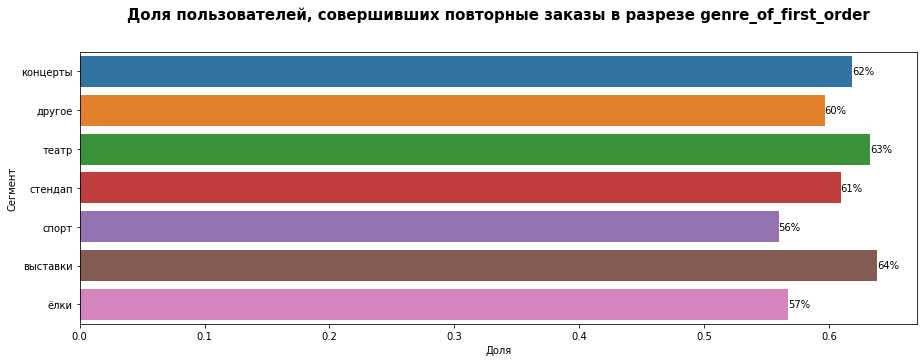

In [40]:
# Вычислим долю и количество пользователей, совершивших два и более заказа
is_two_genre_of_first_order = user_profile.groupby('genre_of_first_order').agg(
    count_all = ('user_id', 'count'),
    count_return = ('is_two', 'sum'),
    share_return = ('is_two', 'mean'),
).sort_values(by='count_return', ascending=False).reset_index()

# Посторим график

plt.figure(figsize=(15, 5))

sns.barplot(data=is_two_genre_of_first_order, x='share_return', y='genre_of_first_order', dodge=False)

plt.title('Доля пользователей, совершивших повторные заказы в разрезе genre_of_first_order', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Доля')
plt.ylabel('Сегмент')

for i, share in enumerate(is_two_genre_of_first_order['share_return']):
    plt.text(share, i, f'{share:.0%}',va='center')

is_two_genre_of_first_order['share_return'] = round(is_two_genre_of_first_order['share_return']*100,2)

print()
print(is_two_genre_of_first_order)
print()
plt.show()


  device_of_first_order  count_all  count_return  share_return
0                mobile      17906         10882         60.77
1               desktop       3732          2388         63.99



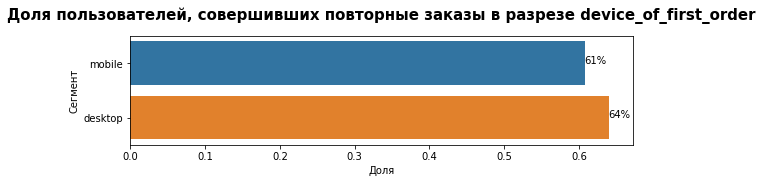

In [41]:
# Вычислим долю пользователей, совершивших два и более заказа
is_two_device_of_first_order = user_profile.groupby('device_of_first_order').agg(
    count_all = ('user_id', 'count'),
    count_return = ('is_two', 'sum'),
    share_return = ('is_two', 'mean'),
).sort_values(by='count_return', ascending=False).reset_index()

# Посторим график

plt.figure(figsize=(9, 2))

sns.barplot(data=is_two_device_of_first_order, x='share_return', y='device_of_first_order', dodge=False)

plt.title('Доля пользователей, совершивших повторные заказы в разрезе device_of_first_order', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Доля')
plt.ylabel('Сегмент')

for i, share in enumerate(is_two_device_of_first_order['share_return']):
    plt.text(share, i, f'{share:.0%}')

is_two_device_of_first_order['share_return'] = round(is_two_device_of_first_order['share_return']*100,2)

print()
print(is_two_device_of_first_order)
print()
plt.show()


  region_of_first_order  count_all  count_return  share_return
0    Каменевский регион       7082          4418         62.38
1  Североярская область       3783          2420         63.97
2   Широковская область       1222           788         64.48
3      Озернинский край        668           366         54.79
4      Шанырский регион        500           336         67.20
5      Травяная область        486           298         61.32
6  Светополянский округ        454           297         65.42
7  Малиновоярский округ        524           293         55.92
8   Речиновская область        439           278         63.33
9   Яблоневская область        409           242         59.17



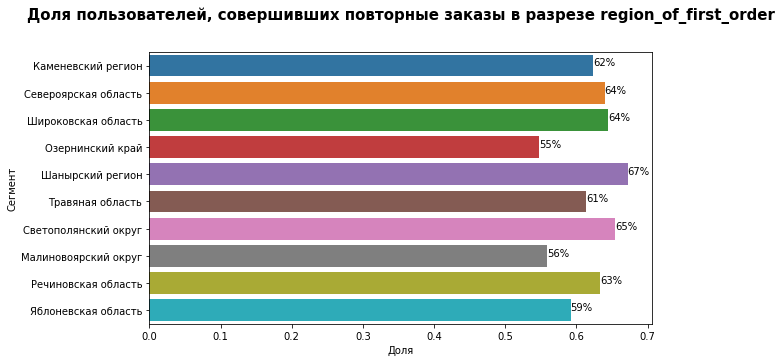

In [42]:
# Вычислим долю пользователей, совершивших два и более заказа
is_two_region_of_first_order = user_profile.groupby('region_of_first_order').agg(
    count_all = ('user_id', 'count'),
    count_return = ('is_two', 'sum'),
    share_return = ('is_two', 'mean'),
).sort_values(by='count_return', ascending=False).reset_index().head(10)

# Посторим график

plt.figure(figsize=(9, 5))

sns.barplot(data=is_two_region_of_first_order, x='share_return', y='region_of_first_order', dodge=False)

plt.title('Доля пользователей, совершивших повторные заказы в разрезе region_of_first_order', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Доля')
plt.ylabel('Сегмент')

for i, share in enumerate(is_two_region_of_first_order['share_return']):
    plt.text(share, i, f'{share:.0%}')

is_two_region_of_first_order['share_return'] = round(is_two_region_of_first_order['share_return']*100,2)

print()
print(is_two_region_of_first_order)
print()
plt.show()


  service_of_first_order  count_all  count_return  share_return
0     Билеты без проблем       5179          3126         60.36
1              Мой билет       2970          1808         60.88
2            Лови билет!       2813          1715         60.97
3          Билеты в руки       2561          1607         62.75
4                Облачко       2185          1342         61.42
5         Весь в билетах       1274           797         62.56
6          Лучшие билеты       1191           732         61.46
7              Прачечная        580           362         62.41
8           Край билетов        455           297         65.27
9           Дом культуры        357           231         64.71



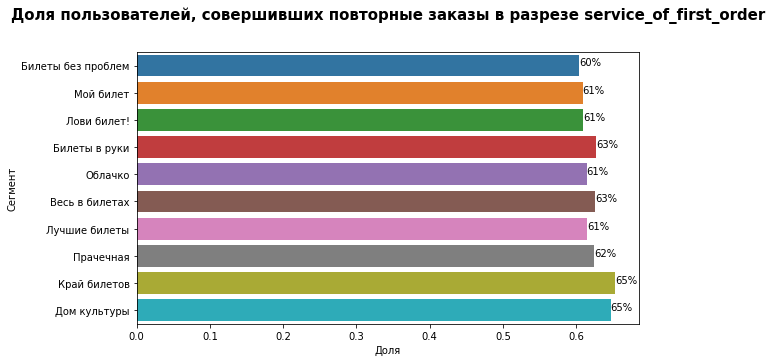

In [43]:
# Вычислим долю пользователей, совершивших два и более заказа
is_two_service_of_first_order = user_profile.groupby('service_of_first_order').agg(
    count_all = ('user_id', 'count'),
    count_return = ('is_two', 'sum'),
    share_return = ('is_two', 'mean'),
).sort_values(by='count_return', ascending=False).reset_index().head(10)

# Посторим график

plt.figure(figsize=(9, 5))

sns.barplot(data=is_two_service_of_first_order, x='share_return', y='service_of_first_order', dodge=False)

plt.title('Доля пользователей, совершивших повторные заказы в разрезе service_of_first_order', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Доля')
plt.ylabel('Сегмент')

for i, share in enumerate(is_two_service_of_first_order['share_return']):
    plt.text(share, i, f'{share:.0%}')

is_two_service_of_first_order['share_return'] = round(is_two_service_of_first_order['share_return']*100,2)

print()
print(is_two_service_of_first_order)
print()
plt.show()

In [44]:
# Фильтруем share
is_two_genre_of_first_order_ = is_two_genre_of_first_order[is_two_genre_of_first_order['share_return'] > share_is_two]
is_two_device_of_first_order_ = is_two_device_of_first_order[is_two_device_of_first_order['share_return'] > share_is_two]
is_two_region_of_first_order_ = is_two_region_of_first_order[is_two_region_of_first_order['share_return'] > share_is_two]
is_two_service_of_first_order_ = is_two_service_of_first_order[is_two_service_of_first_order['share_return'] > share_is_two]

In [45]:
print(f'''
1. Для каждого сегмента вычислили долю пользователей, совершивших два и более заказа.

2. Визуализировали результат с помощью столбчатых диаграмм.

3. Выделили сегменты пользователей, которые чаще возвращаются на Яндекс Афишу по основным классификациям сегментов:
   
    - по типу их первого мероприятия:
''')

for i in range(0,is_two_genre_of_first_order.shape[0]):
        print(f'''        - {is_two_genre_of_first_order.iloc[i,0]} - {is_two_genre_of_first_order.iloc[i,3]}%''')
        
print(f'''   
    Пользователи, которые пришли впервый раз на {is_two_genre_of_first_order.iloc[0,0]}, {is_two_genre_of_first_order.iloc[1,0]}, {is_two_genre_of_first_order.iloc[2,0]} чаще возвращаются во второй раз.  
    
    Лидирующим жанром по доли вернувшихся является {is_two_genre_of_first_order.iloc[5,0]} - {is_two_genre_of_first_order.iloc[5,3]}%.
    Но в абсолютном значении это число небольшое - {is_two_genre_of_first_order.iloc[5,2]} вернувшихся.
    Если брать абсолютное значение, то лидером является {is_two_genre_of_first_order.iloc[0,0]} - {is_two_genre_of_first_order.iloc[0,2]} вернувшихся.
    
    - по типу устройства, с которого совершена первая покупка:
        - {is_two_device_of_first_order.iloc[0,0]} - {is_two_device_of_first_order.iloc[0,3]}%
        - {is_two_device_of_first_order.iloc[1,0]} - {is_two_device_of_first_order.iloc[1,3]}%

    В относительном отношении лидирует {is_two_device_of_first_order.iloc[1,0]} - {is_two_device_of_first_order.iloc[1,3]}
    в абсолютном значении это число - {is_two_device_of_first_order.iloc[1,2]}
    В абсолютном отношении лидирует {is_two_device_of_first_order.iloc[0,0]} -  {is_two_device_of_first_order.iloc[0,2]}

    Доля вернувшихся пользователи, которые впервые заказали с компьютера или мобильного устройства, примерно одинаковая.
    Делаем вывод, что устройство, с которого сделан первый заказ мало влияет на поведение пользователя.
    
    - по региону проведения мероприятия из первого заказа:''')

for i in range(0,10):
        print(f'''        - {is_two_region_of_first_order.iloc[i,0]} - {is_two_region_of_first_order.iloc[i,3]}%''')
        
print(f'''
    Лидером по доли вернувшихся является {is_two_region_of_first_order.iloc[4,0]} - {is_two_region_of_first_order.iloc[4,3]}%.
    Но в абсолютном значении это число не очень впечатляет - всего {is_two_region_of_first_order.iloc[4,2]} вернувшихся.
    Если брать абсолютное значение, то лидером является {is_two_region_of_first_order.iloc[0,0]} - {is_two_region_of_first_order.iloc[0,2]} вернувшихся.
    Большая доля вернувшихся пользователей в регионах скорее всего обусловлена активным продвижением мероприятий и высоком уровнем культурной жизни в этом регионе.

    - по билетному оператору, продавшему билеты на первый заказ:
    ''')

for i in range(0,10):
        print(f'''        - {is_two_service_of_first_order.iloc[i,0]} - {is_two_service_of_first_order.iloc[i,3]}%''')

print(f'''
    Лидером по доли вернувшихся является оператор {is_two_service_of_first_order.iloc[8,0]} - {is_two_service_of_first_order.iloc[8,3]}%.
    Но в абсолютном значении это число небольшое - {is_two_service_of_first_order.iloc[8,2]} вернувшихся.
    Если брать абсолютное значение, то лидером является {is_two_service_of_first_order.iloc[0,0]} - {is_two_service_of_first_order.iloc[0,2]} вернувшихся.
    Возможно, это наиболее популярные операторы, пользующиеся доверием своих клиентов.
        
    - Успешные «точки входа» наблюдаются во всех сегментах.
    
    В среднем по выборке доля пользователей равна {share_is_two}% поэтому выделим следующие успешные «точки входа»:
        - по типу их первого мероприятия: {", ".join(is_two_genre_of_first_order_['genre_of_first_order'])}
        - по типу устройства, с которого совершена первая покупка: {", ".join(is_two_device_of_first_order_['device_of_first_order'])}
        - по региону проведения мероприятия из первого заказа: {", ".join(is_two_region_of_first_order_['region_of_first_order'])}
        - по билетному оператору, продавшему билеты на первый заказ: {", ".join(is_two_service_of_first_order_['service_of_first_order'])}

Но средняя доля вернувшихся пользователей практически не отличается от среднего значения - {share_is_two}%:
- по типу их первого мероприятия: {is_two_genre_of_first_order['share_return'].mean():.0f}%
- по типу устройства: {is_two_device_of_first_order['share_return'].mean():.0f}%
- по региону: {is_two_region_of_first_order['share_return'].mean():.0f}%
- по билетному оператору: {is_two_service_of_first_order['share_return'].mean():.0f}%

Сделаем вывод, что сегменты мало влияют на поведение пользователей.
''')


1. Для каждого сегмента вычислили долю пользователей, совершивших два и более заказа.

2. Визуализировали результат с помощью столбчатых диаграмм.

3. Выделили сегменты пользователей, которые чаще возвращаются на Яндекс Афишу по основным классификациям сегментов:
   
    - по типу их первого мероприятия:

        - концерты - 61.83%
        - другое - 59.65%
        - театр - 63.31%
        - стендап - 60.94%
        - спорт - 55.96%
        - выставки - 63.83%
        - ёлки - 56.7%
   
    Пользователи, которые пришли впервый раз на концерты, другое, театр чаще возвращаются во второй раз.  
    
    Лидирующим жанром по доли вернувшихся является выставки - 63.83%.
    Но в абсолютном значении это число небольшое - 263 вернувшихся.
    Если брать абсолютное значение, то лидером является концерты - 5912 вернувшихся.
    
    - по типу устройства, с которого совершена первая покупка:
        - mobile - 60.77%
        - desktop - 63.99%

    В относительном отношении лидирует desktop - 

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Первая гипотеза** предполагает, что тип мероприятия влияет на вероятность возврата на Яндекс Афиш, а пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Данные, полученные из решения задач, следующие:
   -  В сегменте `спорт` доля пользователей, совершивших два и более заказа равна 55.96%.
   -  В сегменте `концерты` доля пользователей, совершивших два и более заказа равна 61.83%.

Доля пользователей, совершивших два и более заказа в сегменте `спорт` ниже, чем сегменте `концерты` на 5,87%.

Следовательно первая гипотеза ошибочна.

Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на концерты, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на спортивные мероприятия.

**Вторая гипотеза** предполагает, что в регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Данные, полученные из решения задач, следующие:
   - У `Каменевского региона` наибольшее число пользователей - 7082, а доля повторных заказов - 62.38%.
   - В следующих регионах доля повторных заказов больше, а число пользователей меньше:
       - `Шанырский регион` (число пользователей - 500, доля повторных заказов - 67%); 
       - `Светополянский округ` (число пользователей - 454, доля повторных заказов - 65%);
       - `Широковская область` (число пользователей - 1222, доля повторных заказов - 64%);
       - `Североярская область` (число пользователей - 454, доля повторных заказов - 64%);
       - `Речиновская область` (число пользователей - 439, доля повторных заказов - 63%).
       
Доля повторных заказов в регионах, где больше всего пользователей посещают мероприятия, ниже, чем в менее активных регионах.

Следовательно вторая гипотеза также ошибочна.

Доля повторных заказов не зависит от большего количества пользователей, посещающих мероприятия.

---

#### Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


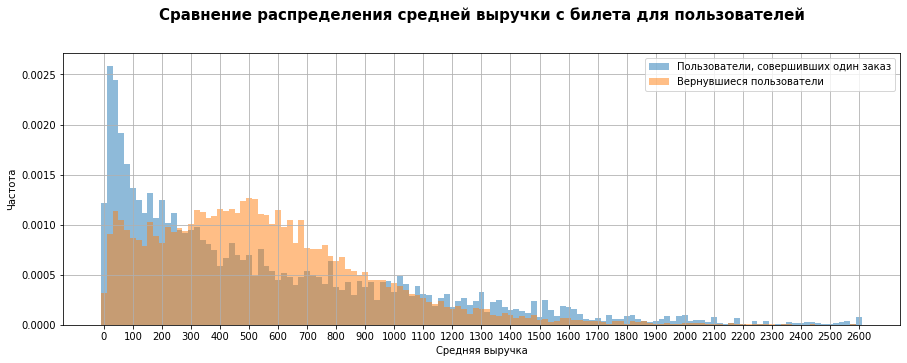

In [46]:
import numpy as np

# Группируем пользователей по количеству заказов
users_who_made_one_order = user_profile[user_profile['total_number_of_orders'] == 1]['average_revenue_in_rubles']
returning_users = user_profile[user_profile['total_number_of_orders'] > 1]['average_revenue_in_rubles']

# Находим минимальное и максимальное значения
min_value = min(users_who_made_one_order.min(), returning_users.min()).astype('int')
max_value = max(users_who_made_one_order.max(), returning_users.max()).astype('int')

users_who_made_one_order.plot(
    kind='hist',
    density=True,
    bins=range(min_value, max_value+1, 20),
    alpha=0.5,
    label='Пользователи, совершивших один заказ',
    legend=True,
    figsize =(15, 5)
    )

returning_users.plot(
    kind='hist',
    density=True,
    bins=range(min_value, max_value+1, 20),
    alpha=0.5,
    label='Вернувшиеся пользователи',
    legend=True,
    figsize =(15, 5)
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title('Сравнение распределения средней выручки с билета для пользователей', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Средняя выручка')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()
plt.xticks(np.arange(0, max_value, 100))
# Выводим график
plt.show()

In [47]:
print(f'''
1. Построили сравнительные гистограммы распределения средней выручки с билета для пользователей, совершивших один заказ и для вернувшихся пользователей, совершивших 2 и более заказа.

2. Определили, что пользователей, совершившие один заказ, концентрируются в диапазоне средней выручки от 0 до 500 руб. 
А вернувшихся пользователей концентрируются в диапазоне средней выручки от 10 до 1000 руб.
Это говорит о том, что вернувшиеся пользователи покупают более дорогие билеты.

3. Установили различия между группами:

- по графику распределения:
    - пользователи, совершившие один заказ: распределение правоасимметричное, мода или пик распределения находится в диапазоне низких цен.
    - пользователи, совершившие 2 и более заказа: пик распределения ниже и правее, чем у пользователей, совершившие один заказ

- по статистическим показателям:
    - пользователи, совершившие один заказ:
        - количество - {users_who_made_one_order.count():.0f}
        - стандартное отклонение - {users_who_made_one_order.std():.0f}
        - медиана - {users_who_made_one_order.quantile(0.5):.0f}
    - пользователи, совершившие 2 и более заказа:
        - количество - {returning_users.count():.0f}
        - стандартное отклонение - {returning_users.std():.0f}
        - медиана - {returning_users.quantile(0.5):.0f}

Количество пользователей, совершившие 2 и более заказа больше, чем одноразовых пользователей.
Стандартное отклонение в цене покупки больше у одноразовых пользователей.
А медиана больше у пользователей, совершившие 2 и более заказа.

Такое различие в распределении указывает на то, что большинство одноразовых пользователей покупают дешевые билеты и их спрос на них зависит от цены. Это характерно для спонтанных покупок.

Вернувшихся пользователей больше, чем одноразовых, они готовы платить за более дорогой билет и их спрос меньше зависит от цены, что говорит о их заинтересованности в посещении различных мероприятий.
''')


1. Построили сравнительные гистограммы распределения средней выручки с билета для пользователей, совершивших один заказ и для вернувшихся пользователей, совершивших 2 и более заказа.

2. Определили, что пользователей, совершившие один заказ, концентрируются в диапазоне средней выручки от 0 до 500 руб. 
А вернувшихся пользователей концентрируются в диапазоне средней выручки от 10 до 1000 руб.
Это говорит о том, что вернувшиеся пользователи покупают более дорогие билеты.

3. Установили различия между группами:

- по графику распределения:
    - пользователи, совершившие один заказ: распределение правоасимметричное, мода или пик распределения находится в диапазоне низких цен.
    - пользователи, совершившие 2 и более заказа: пик распределения ниже и правее, чем у пользователей, совершившие один заказ

- по статистическим показателям:
    - пользователи, совершившие один заказ:
        - количество - 8368
        - стандартное отклонение - 520
        - медиана - 378
    - пользователи, с

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


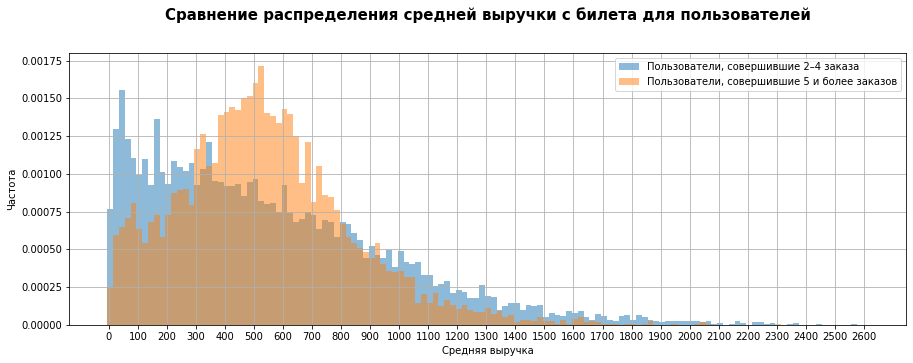

In [48]:
# Группируем пользователей по количеству заказов

users_who_made_two_four_orders = user_profile[(user_profile['total_number_of_orders'] >= 2)&
        (user_profile['total_number_of_orders'] <= 4)]['average_revenue_in_rubles']
users_who_made_five_or_more_orders = user_profile[user_profile['total_number_of_orders'] >= 5]['average_revenue_in_rubles']

# Находим минимальное и максимальное значения
min_value = min(users_who_made_two_four_orders.min(), users_who_made_five_or_more_orders.min()).astype('int')
max_value = max(users_who_made_two_four_orders.max(), users_who_made_five_or_more_orders.max()).astype('int')

users_who_made_two_four_orders.plot(
    kind='hist',
    density=True,
    bins=range(min_value, max_value+1, 20),
    alpha=0.5,
    label='Пользователи, совершившие 2–4 заказа',
    legend=True,
    figsize =(15, 5)
    )

users_who_made_five_or_more_orders.plot(
    kind='hist',
    density=True,
    bins=range(min_value, max_value+1, 20),
    alpha=0.5,
    label='Пользователи, совершившие 5 и более заказов',
    legend=True,
    figsize =(15, 5)
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title('Сравнение распределения средней выручки с билета для пользователей', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Средняя выручка')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()
plt.xticks(np.arange(0, max_value, 100))
# Выводим график
plt.show()

In [49]:
print(f'''
1. Построили сравнительные гистограммы распределения средней выручки с билета для пользователей, совершивших 2–4 заказа и для вернувшихся пользователей, совершивших 5 и более заказов.

2. Определили, что пользователей, совершившие 2–4 заказа, концентрируются в диапазоне средней выручки от 0 до 600 руб. 
А пользователи, совершившие 5 и более заказов концентрируются в диапазоне средней выручки от 200 до 800 руб.

Это говорит о том, что пользователи, совершившие 5 и более заказов покупают более дорогие билеты, чем совершившие 2–4 заказа.

2. Установили различия между группами:

- по концентрации в диапазоне средней выручки:
    - пользователи, совершившие 2–4 заказа: 0-350
    - пользователи, совершившие 5 и более заказов: 300-700
    
- по графику распределения:
    - пользователи, совершившие 2–4 заказа: распределение правоасимметричное, мода или пик распределения находится в диапазоне низких цен.
    - пользователи, совершившие 5 и более заказов: пик распределения находится выше и правее.

- по статистическим показателям:
    - пользователи, совершившие 2–4 заказа:
        - количество - {users_who_made_two_four_orders.count():.0f}
        - стандартное отклонение - {users_who_made_two_four_orders.std():.0f}
        - медиана - {users_who_made_two_four_orders.quantile(0.5):.0f}
    - пользователи, совершившие 5 и более заказов:
        - количество - {users_who_made_five_or_more_orders.count():.0f}
        - стандартное отклонение - {users_who_made_five_or_more_orders.std():.0f}
        - медиана - {users_who_made_five_or_more_orders.quantile(0.5):.0f}

Количество пользователей, совершившие 2–4 заказа больше, чем пользователей, совершившие 5 и более заказов. 
Стандартное отклонение в цене покупки больше у пользователей, совершившие 2–4 заказа больше.
А медиана больше у пользователей, совершившие 5 и более заказов.

Подобное различие указывает на то, что пользователей, совершившие 5 и более заказов, меньше, чем пользователей, совершившие 2–4 заказа. Они склонны покупать более дорогие билеты и их спрос на билеты меньше зависит от цен.
''')


1. Построили сравнительные гистограммы распределения средней выручки с билета для пользователей, совершивших 2–4 заказа и для вернувшихся пользователей, совершивших 5 и более заказов.

2. Определили, что пользователей, совершившие 2–4 заказа, концентрируются в диапазоне средней выручки от 0 до 600 руб. 
А пользователи, совершившие 5 и более заказов концентрируются в диапазоне средней выручки от 200 до 800 руб.

Это говорит о том, что пользователи, совершившие 5 и более заказов покупают более дорогие билеты, чем совершившие 2–4 заказа.

2. Установили различия между группами:

- по концентрации в диапазоне средней выручки:
    - пользователи, совершившие 2–4 заказа: 0-350
    - пользователи, совершившие 5 и более заказов: 300-700
    
- по графику распределения:
    - пользователи, совершившие 2–4 заказа: распределение правоасимметричное, мода или пик распределения находится в диапазоне низких цен.
    - пользователи, совершившие 5 и более заказов: пик распределения находится выше и пра

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [50]:
user_profile['average_number_of_tickets'].describe().to_frame().round(2)

,average_number_of_tickets
count,21638.00
mean,2.74
std,0.92
min,1.00
25%,2.00
50%,2.75
75%,3.10
max,11.00


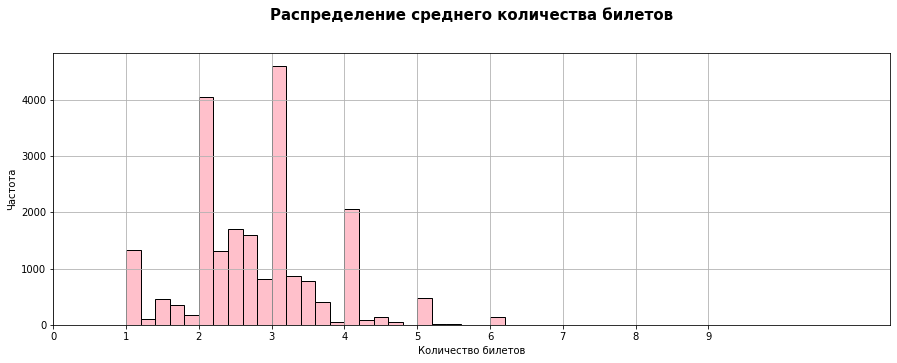

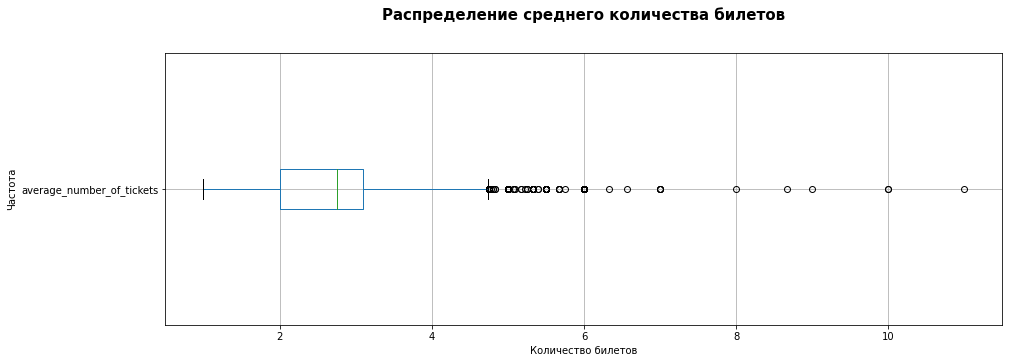

In [51]:
# Строим гистограмму

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5)) 
user_profile['average_number_of_tickets'].plot(
    kind='hist', 
    bins=50, 
    rot=0, 
    color = 'pink', 
    edgecolor='black')
# Настраиваем оформление графика
plt.title('Распределение среднего количества билетов', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()
plt.xticks(np.arange(0, 10, 1))
# Выводим график
plt.show()

# Строим "ящик с усами"

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))
# Строим диаграмму размаха значений в столбце tickets_count
user_profile.boxplot(column='average_number_of_tickets', vert=False)
# Добавляем заголовок и метки оси
plt.title('Распределение среднего количества билетов', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
# Выводим график
plt.show()

In [52]:
user_profile['ticket_quantity_segment'] = pd.cut(user_profile['average_number_of_tickets'], 
    bins=[0, 2, 3, 5, max(user_profile['average_number_of_tickets'])], 
    labels=["от 1 до 2 билетов", "от 2 до 3 билетов", "от 3 до 5 билетов", "от 5 и более билетов"])

In [53]:
segment_number_of_tickets = user_profile.groupby('ticket_quantity_segment').agg(
    total_number_of_users = ('user_id', 'count'), # общее число пользователей
    share_of_returning_users = ('is_two', 'mean') # доля пользователей, совершивших повторные заказы
).reset_index()

segment_number_of_tickets['share_of_returning_users'] = round(segment_number_of_tickets['share_of_returning_users']*100,2)

segment_number_of_tickets = segment_number_of_tickets.sort_values(by='total_number_of_users', ascending=False).reset_index(drop=True)

segment_number_of_tickets

,ticket_quantity_segment,total_number_of_users,share_of_returning_users
0,от 2 до 3 билетов,9935,74.28
1,от 1 до 2 билетов,6160,40.15
2,от 3 до 5 билетов,5349,62.70
3,от 5 и более билетов,194,32.47


In [54]:
print(f'''
1. Изучили распределение пользователей по среднему количеству билетов в заказе:
    - Распределение относительно симметричное, присутствуют редкие выбросы.
    - Среднее значение ({user_profile['average_number_of_tickets'].mean():.2f}) равна медиане ({user_profile['average_number_of_tickets'].quantile(0.5):.2f})    
    - 50% пользователей в среднем покупают по 2 или 3 билета;
    - Невысокое стандартное отклонение ({user_profile['average_number_of_tickets'].std():.2f}) означает, что пользователи в целом приобретают примерно одинаковое количество билетов, и разброс значений невелик. 

2. Разделили пользователей на несколько сегментов по среднему количеству билетов в заказе.

3. Для каждого сегмента подсчитали общее число пользователей и долю пользователей, совершивших повторные заказы.

4. Выяснили, что пользователи распределены по сегментам сконцентрировано.

    - Наибольшее количество пользователей принадлежит сегменту {segment_number_of_tickets.iloc[0,0]} ({segment_number_of_tickets.iloc[0,1]}).
    - Далее по количеству пользователей идет сегменты {segment_number_of_tickets.iloc[1,0]} ({segment_number_of_tickets.iloc[1,1]}) и {segment_number_of_tickets.iloc[2,0]} ({segment_number_of_tickets.iloc[2,1]}).
    - Самые редкие заказы {segment_number_of_tickets.iloc[3,0]} ({segment_number_of_tickets.iloc[3,1]}).

5. Определили сегменты с аномально высокой или низкой долей повторных покупок:
    
    Наибольшая доля пользователей, совершивших повторные заказы в сегменте {segment_number_of_tickets.iloc[0,0]} - {segment_number_of_tickets.iloc[0,2]}%
    Наименьшая доля пользователей, совершивших повторные заказы в сегменте {segment_number_of_tickets.iloc[3,0]} - {segment_number_of_tickets.iloc[3,2]}%)
    
Большинство пользователей приобретает по 2-3 билета. 
Самые непопулярный сегмент - от 5 и более билетов. 
Редко кто покупает билеты на целую группу и существует низкая вероятность, что пользователи возвратятся.
    ''')


1. Изучили распределение пользователей по среднему количеству билетов в заказе:
    - Распределение относительно симметричное, присутствуют редкие выбросы.
    - Среднее значение (2.74) равна медиане (2.75)    
    - 50% пользователей в среднем покупают по 2 или 3 билета;
    - Невысокое стандартное отклонение (0.92) означает, что пользователи в целом приобретают примерно одинаковое количество билетов, и разброс значений невелик. 

2. Разделили пользователей на несколько сегментов по среднему количеству билетов в заказе.

3. Для каждого сегмента подсчитали общее число пользователей и долю пользователей, совершивших повторные заказы.

4. Выяснили, что пользователи распределены по сегментам сконцентрировано.

    - Наибольшее количество пользователей принадлежит сегменту от 2 до 3 билетов (9935).
    - Далее по количеству пользователей идет сегменты от 1 до 2 билетов (6160) и от 3 до 5 билетов (5349).
    - Самые редкие заказы от 5 и более билетов (194).

5. Определили сегменты с аномал

---

#### Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [55]:
days_dict = {
    0:'Понедельник', 1:'Вторник', 2:'Среда', 3:'Четверг', 4:'Пятница', 5:'Суббота', 6:'Воскресенье'}

user_profile['days_of_the_week'] = user_profile['date_of_first_order'].dt.dayofweek.map(days_dict)

  days_of_the_week  total_number_of_users  share_of_returning_users
0      Понедельник                   2930                     63.04
1          Суббота                   3326                     62.81
2            Среда                   3057                     62.19
3          Вторник                   3176                     61.90
4      Воскресенье                   2777                     60.03
5          Пятница                   3259                     59.83
6          Четверг                   3113                     59.43



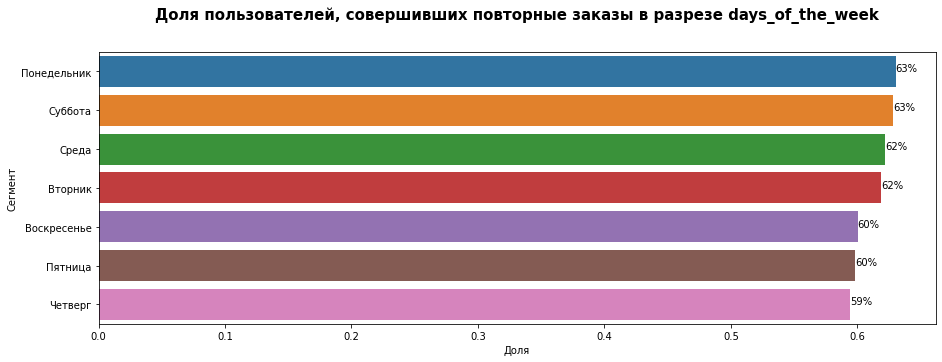

In [56]:
day_of_the_week_segment = user_profile.groupby('days_of_the_week').agg(
    total_number_of_users = ('user_id', 'count'), # общее число пользователей
    share_of_returning_users = ('is_two', 'mean') # доля пользователей, совершивших повторные заказы
).reset_index()

day_of_the_week_segment = day_of_the_week_segment.sort_values(by='share_of_returning_users', ascending=False).reset_index(drop=True)

# Посторим график

plt.figure(figsize=(15, 5))

sns.barplot(data=day_of_the_week_segment, x='share_of_returning_users', y='days_of_the_week')

plt.title('Доля пользователей, совершивших повторные заказы в разрезе days_of_the_week', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Доля')
plt.ylabel('Сегмент')

for i, share in enumerate(day_of_the_week_segment['share_of_returning_users']):
    plt.text(share, i, f'{share:.0%}')

day_of_the_week_segment['share_of_returning_users'] = round(day_of_the_week_segment['share_of_returning_users']*100,2)

print(day_of_the_week_segment)
print()   

plt.show()

In [57]:
print(f'''
1. По данным даты первого заказа выделили день недели.

2. Для каждого дня недели подсчитали общее число пользователей и долю пользователей, совершивших повторные заказы. 
Результаты визуализировали.

3. Определили, что день недели, в которую совершена первая покупка, не влияет на вероятность возврата клиента.

    Вернувшиеся пользователи распределены по дням недели равномерно. Вариация доли находится в диапазоне 59% - 63% и не сильно отклоняется от среднего значения ({share_is_two*100:.0f}).
''')


1. По данным даты первого заказа выделили день недели.

2. Для каждого дня недели подсчитали общее число пользователей и долю пользователей, совершивших повторные заказы. 
Результаты визуализировали.

3. Определили, что день недели, в которую совершена первая покупка, не влияет на вероятность возврата клиента.

    Вернувшиеся пользователи распределены по дням недели равномерно. Вариация доли находится в диапазоне 59% - 63% и не сильно отклоняется от среднего значения (6100).



---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [58]:
avg_time_users_who_made_two_four_orders = user_profile[(user_profile['total_number_of_orders'] >= 2)&
        (user_profile['total_number_of_orders'] <= 4)]['average_time_between_orders']
avg_time_users_who_made_five_or_more_orders = user_profile[user_profile['total_number_of_orders'] >= 5]['average_time_between_orders']

In [59]:
avg_time_users_who_made_two_four_orders_describe = avg_time_users_who_made_two_four_orders.describe().to_frame()
avg_time_users_who_made_five_or_more_orders_describe=avg_time_users_who_made_five_or_more_orders.describe().to_frame()

In [60]:
# Объединим таблицы для сравнения
avg_time_users_describe = avg_time_users_who_made_two_four_orders_describe.join(avg_time_users_who_made_five_or_more_orders_describe, lsuffix='_two_four_orders', rsuffix='_five_or_more_orders').round()

# Выведем статистические данные 
avg_time_users_describe

,average_time_between_orders_two_four_orders,average_time_between_orders_five_or_more_orders
count,7147.0,6123.0
mean,21.0,10.0
std,28.0,8.0
min,0.0,0.0
25%,0.0,4.0
50%,9.0,8.0
75%,34.0,14.0
max,148.0,38.0


In [61]:
avg_time_users_who_made_two_four_orders.max().astype('int')

148

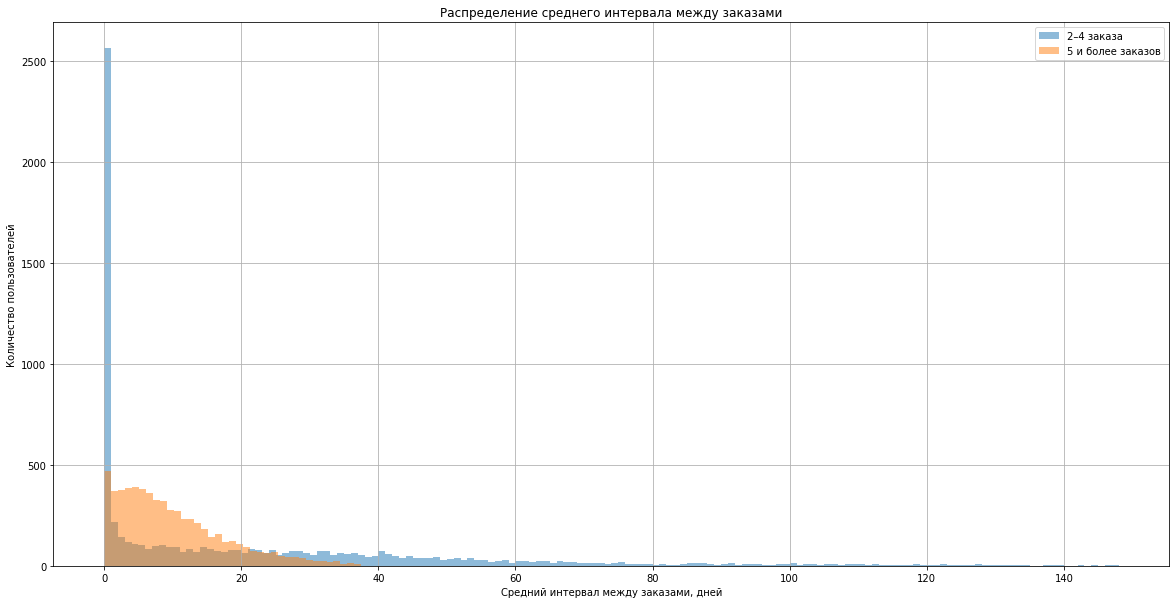

In [62]:
plt.figure(figsize=(20, 10))

plt.hist(
    avg_time_users_who_made_two_four_orders,
    bins=avg_time_users_who_made_two_four_orders.max().astype('int'),
    alpha=0.5,
    label='2–4 заказа')

plt.hist(
    avg_time_users_who_made_five_or_more_orders,
    bins=avg_time_users_who_made_five_or_more_orders.max().astype('int'),
    alpha=0.5,
    label='5 и более заказов')

plt.title('Распределение среднего интервала между заказами')
plt.xlabel('Средний интервал между заказами, дней')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()

plt.show()

In [63]:
print(f'''
1. Рассчитали среднее время между заказами для двух групп пользователей совершившие 2–4 заказа и совершившие 5 и более заказов

2. Cредний интервал между заказами влияет на вероятность повторного заказа.

Пользователи, совершившие 2–4 заказа возвращаются в среднем каждые {avg_time_users_who_made_two_four_orders.mean():.2f} дня.
Пользователи, совершившие 5 и более заказов возвращаются в среднем {avg_time_users_who_made_five_or_more_orders.mean():.2f} дня.

Частые покупки подтверждает лояльность пользователей, совершивших 5 и более заказов.

3. Изучили распределение среднего интервала между заказами.

Различия между группами:

- по графику распределения: график распределения интервала пользователей, совершившие 5 и более заказов выше графика интервала пользователей, совершившие 2-4 заказа.
Это говорит пользователей, совершившие 5 и более заказов покупают чаще, чем пользователи, совершившие 2-4 заказа.

- по статистическим показателям:
    - пользователи, совершившие 2-4 заказа:
        - количество - {avg_time_users_describe.iloc[0,0]}
        - стандартное отклонение - {avg_time_users_describe.iloc[2,0]}
        - среднее значение - {avg_time_users_describe.iloc[1,0]}
    - пользователи, совершившие 5 и более заказов:
        - количество - {avg_time_users_describe.iloc[0,1]}
        - стандартное отклонение - {avg_time_users_describe.iloc[2,1]}
        - среднее значение - {avg_time_users_describe.iloc[1,1]}

Количество пользователей, совершившие 2–4 заказа больше, чем пользователей, совершившие 5 и более заказов. 
Стандартное отклонение в интервале покупки больше у пользователей, совершившие 2–4 заказа больше.
Средний интервал между заказами у пользователей, совершившие 2–4 заказа больше, чем пользователей, совершившие 5 и более заказов. 

Таким образом средний интервал между заказами влияет на удержанием пользователей.
Чем меньше интевал, тем выше вероятность, что пользователь совершит больше покупок билетов.
''')


1. Рассчитали среднее время между заказами для двух групп пользователей совершившие 2–4 заказа и совершившие 5 и более заказов

2. Cредний интервал между заказами влияет на вероятность повторного заказа.

Пользователи, совершившие 2–4 заказа возвращаются в среднем каждые 21.32 дня.
Пользователи, совершившие 5 и более заказов возвращаются в среднем 9.90 дня.

Частые покупки подтверждает лояльность пользователей, совершивших 5 и более заказов.

3. Изучили распределение среднего интервала между заказами.

Различия между группами:

- по графику распределения: график распределения интервала пользователей, совершившие 5 и более заказов выше графика интервала пользователей, совершившие 2-4 заказа.
Это говорит пользователей, совершившие 5 и более заказов покупают чаще, чем пользователи, совершившие 2-4 заказа.

- по статистическим показателям:
    - пользователи, совершившие 2-4 заказа:
        - количество - 7147.0
        - стандартное отклонение - 28.0
        - среднее значение - 21.0
   

Определим наиболее продуктивный интевал между заказами у пользователей, совершившие 5 и более заказов.

In [64]:
user_profile['avg_time_segment'] = pd.cut(
    user_profile['average_time_between_orders'],
    bins=[0, 7, 14, 21, 28, user_profile['average_time_between_orders'].max()],
    labels=['до 7 дней', 'от 7 до 14 дней', 'от 14 до 21 дней', 'от 21 до 28 дней', 'от 28 и более дней'])

In [65]:
is_five_interval_segments = user_profile.groupby('avg_time_segment').agg(
    is_five_count = ('is_five', 'sum'),
    is_five_share = ('is_five', 'mean')).reset_index()

is_five_interval_segments['is_five_share'] = round(is_five_interval_segments['is_five_share']*100)

is_five_interval_segments

,avg_time_segment,is_five_count,is_five_share
0,до 7 дней,2441,72.0
1,от 7 до 14 дней,1874,76.0
2,от 14 до 21 дней,917,63.0
3,от 21 до 28 дней,421,47.0
4,от 28 и более дней,196,8.0


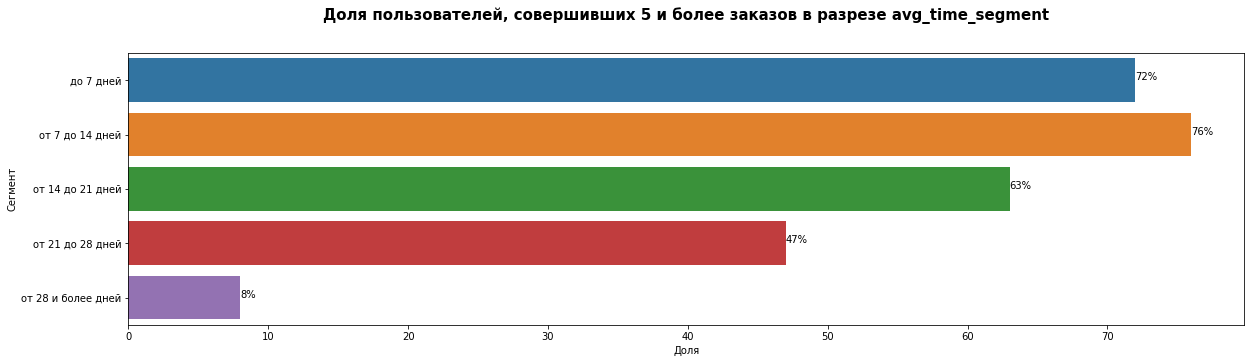

In [66]:
# Посторим график

plt.figure(figsize=(20, 5))

sns.barplot(data=is_five_interval_segments, x='is_five_share', y='avg_time_segment')

plt.title('Доля пользователей, совершивших 5 и более заказов в разрезе avg_time_segment', fontsize=15, fontweight='bold', y=1.1)
plt.xlabel('Доля')
plt.ylabel('Сегмент')

for i, share in enumerate(is_five_interval_segments['is_five_share']):
    plt.text(share, i, f'{share:.0f}%')


plt.show()

In [67]:
print(f'''
Самая высокая доля пользователей, совершившим 5 и более заказов в сегменте {is_five_interval_segments.iloc[1,0]} - {is_five_interval_segments.iloc[1,2]}%
Далее {is_five_interval_segments.iloc[2,0]} - {is_five_interval_segments.iloc[2,2]}% и {is_five_interval_segments.iloc[3,0]} - {is_five_interval_segments.iloc[3,2]}%
И через 28 дней доля резко падает до {is_five_interval_segments.iloc[4,2]}%

Чем больше проходит дней, чем ниже процент вернувшихся пользователей.
''')


Самая высокая доля пользователей, совершившим 5 и более заказов в сегменте от 7 до 14 дней - 76.0%
Далее от 14 до 21 дней - 63.0% и от 21 до 28 дней - 47.0%
И через 28 дней доля резко падает до 8.0%

Чем больше проходит дней, чем ниже процент вернувшихся пользователей.



---

#### Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [68]:
# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

In [69]:
user_profile['interval_cols'] = pd.cut(user_profile['total_number_of_orders'], 
    bins=[0, 1, 4, max(user_profile['total_number_of_orders'])], 
    labels=["1 заказ", "от 2 до 4 заказов", "от 5 и выше"])

In [70]:
correlation_matrix = user_profile[[
    'device_of_first_order', 
    'region_of_first_order', 
    'service_of_first_order', 
    'genre_of_first_order',
    'average_revenue_in_rubles', 
    'average_number_of_tickets',
    'average_time_between_orders',
    'interval_cols']].phik_matrix()
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'interval_cols'][['interval_cols']].sort_values(by='interval_cols', ascending=False)
data_heatmap_ =data_heatmap.reset_index().rename(columns={'index': 'interval_cols', 'interval_cols': 'corr'})
print(data_heatmap)

interval columns not set, guessing: ['average_revenue_in_rubles', 'average_number_of_tickets', 'average_time_between_orders']
                             interval_cols
average_time_between_orders       0.390148
average_number_of_tickets         0.383366
average_revenue_in_rubles         0.326091
region_of_first_order             0.126330
service_of_first_order            0.076092
genre_of_first_order              0.039117
device_of_first_order             0.018397


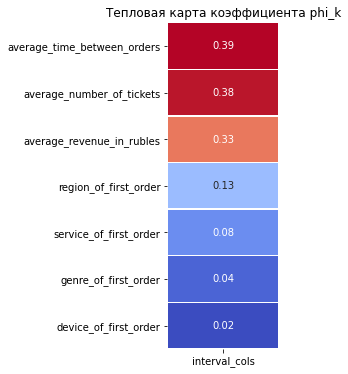

In [71]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
sns.heatmap(data_heatmap, annot=True,fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=False)

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k')
#plt.xlabel('Сегмент по количеству заказов')

# Выводим график
plt.show()

In [72]:
print(f'''
1. Рассчитали коэффициент корреляции phi_k между признаками профиля пользователя и сегментами по количеству заказов.

2. Визуализировали результаты корреляции с помощью тепловой карты.

3. Признаки наиболее связанные с количеством заказов:
    - среднее время между заказами - {data_heatmap_.iloc[0,1]:.2f}
    - среднее количество билетов - {data_heatmap_.iloc[1,1]:.2f}
    - средняя выручка - {data_heatmap_.iloc[2,1]:.2f}

Чем меньше средний интервал между заказами, чем выше среднее количество билетов и чем больше пользователь платит за билет, тем больше вероятность, что пользователь вернется снова. 

То есть основные факторы влияющие на прогноз поведения пользователя: частота и объем купленных билетов и цена, которую он платит за билет.
''')


1. Рассчитали коэффициент корреляции phi_k между признаками профиля пользователя и сегментами по количеству заказов.

2. Визуализировали результаты корреляции с помощью тепловой карты.

3. Признаки наиболее связанные с количеством заказов:
    - среднее время между заказами - 0.39
    - среднее количество билетов - 0.38
    - средняя выручка - 0.33

Чем меньше средний интервал между заказами, чем выше среднее количество билетов и чем больше пользователь платит за билет, тем больше вероятность, что пользователь вернется снова. 

То есть основные факторы влияющие на прогноз поведения пользователя: частота и объем купленных билетов и цена, которую он платит за билет.



### Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

1. Анализ проводился на основании данных датасета, содержащим информацию о заказах пользователей на онлайн-сервисе Яндекс.Афиша. Датасет содержит 290611 строк и 15 столбцов.

2. Были выполнены следующие этапы предобработки данных:
    - Привели выручку по курсу тенге к российскому рублю для обеспечения сопоставимости данных.
    - Оптимизировали типы данных с понижением разрядности для снижения объема используемой памяти.
    - Отфильтровали аномальные значения в столбце revenue_rub по 99 перцентилю (0.97% строк) для повышения точности анализа и достоверности результатов.

3. Создали профиль для описания поведения пользователей. В профиле отфильтровали выбросы в столбце total_number_of_orders. В результате осталось 21638 уникальных пользователей.

4. Провели исследовательский анализ данных. Выявили основные признаки, влияющих на возврат пользователей. Результаты анализа следующие:

    - Доля пользователей с 2 и более заказами составляет около 61%, а доля пользователей с 5 и более заказами — 28%. Это говорит о наличии большой доли лояльных пользователей.

    - Сегментами с наибольшим числом пользователей являются: 
        - по типу их первого мероприятия - 'концерты' (44%), 
        - по типу устройства, с которого совершена первая покупка - 'mobile' (83%), по региону проведения мероприятия из первого заказа - 'Каменевский регион' (33%) 
        - по билетному оператору, продавшему билеты на первый заказ - 'Билеты без проблем' (24%)

    - Сегментами с наибольшим числом вернувшихся во второй раз пользователей являются:
        - по типу их первого мероприятия: выставки (64%), театр (63%), концерты (62%)
        - по типу устройства, с которого совершена первая покупка: desktop (64%)
        - по региону проведения мероприятия из первого заказа: Шанырский регион (67%), Светополянский округ (65%), Широковская область (64%), Североярская область (64%), Речиновская область (63%), Каменевский регион (62%)
        - по билетному оператору, продавшему билеты на первый заказ: Край билетов (65%), Дом культуры (65%), Билеты в руки (63%), Весь в билетах (63%), Прачечная (62%), Лучшие билеты (61%), Облачко (61%)
        
        - В разрезе признаков первого заказа различия в удержании пользователей оказались незначительными. 

    - Cвязь между средней выручкой сервиса с заказа и повторными заказами прямая – вернувшиеся пользователи готовы к более дорогостоящим покупкам. Медиана выручки пользователей, совершивших один заказ – 378 руб., пользователей, совершивших 2–4 заказа – 471 руб., пользователей совершивших 5 и более заказов – 513 руб.

    - Большинство пользователей приобретает по 2-3 билета. Их доля составляет 
    74%.

    - Пользователи, совершившие 2–4 заказа возвращаются в среднем каждые 21 день. Пользователи, совершившие 5 и более заказов возвращаются в среднем через 9 дней.

    - Самая сильная корреляция с количеством заказов наблюдается у следующих признаков:  среднее время между заказами (0.39), среднее количество билетов (0.38) и средняя выручка (0.33). Чем чаще покупает пользователь, чем больше билетов покупает пользователь и чем дороже его покупка, тем выше вероятность его возвращения.



Рекомендации: 

- Анализ показал, что первый заказ не сильно влияет на поведение пользователей в дальнейшем, поэтому концентрироваться на этом не рекомендуем.
- Использовать выраженные «точки входа» - выставки, театр и концерты – для привлечения потенциальных клиентов.
- Сокращать интервал между заказами.
- Привлекать пользователей, которые не возвращались больше 14 дней.
- Разрабатывать стратегии относительно сегмента пользователей, покупающих 2–3 билета.


### Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**